In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [30]:
pairs_df = pd.read_csv("pairs_labeled.csv")

train_df, test_df = train_test_split(
    pairs_df, test_size=0.3, random_state=42, stratify=pairs_df["label"]
)

train_df.to_csv("train_pairs.csv", index=False)
test_df.to_csv("test_pairs.csv", index=False)

print(f"✅ Train set: {len(train_df)} cặp | Test set: {len(test_df)} cặp")
print(train_df['label'].value_counts(normalize=True))

✅ Train set: 362 cặp | Test set: 156 cặp
label
1    0.5
0    0.5
Name: proportion, dtype: float64


In [31]:
import os, tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models

In [32]:
TRAIN_PAIRS = "train_pairs.csv"
TEST_PAIRS  = "test_pairs.csv"
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
EPOCHS      = 10
MODEL_PATH  = "siamese_model.h5"

In [33]:
train_df = pd.read_csv(TRAIN_PAIRS)
test_df  = pd.read_csv(TEST_PAIRS)
print(f"Train pairs: {len(train_df)} | Test pairs: {len(test_df)}")

Train pairs: 362 | Test pairs: 156


In [34]:
def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)  # chuẩn hóa ImageNet
    return img

def make_dataset(df, shuffle=True):
    paths_a = df["path_a"].tolist()
    paths_b = df["path_b"].tolist()
    labels  = df["label"].astype(np.float32).tolist()

    ds = tf.data.Dataset.from_tensor_slices((paths_a, paths_b, labels))
    
    def process_pair(a, b, y):
        return (load_and_preprocess(a), load_and_preprocess(b)), y
    
    ds = ds.map(process_pair, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=1024, seed=42)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
test_ds  = make_dataset(test_df, shuffle=False)

In [35]:
def build_siamese_model():
    # Base CNN (ResNet50)
    base_cnn = ResNet50(weights="imagenet", include_top=False, pooling="avg")
    base_cnn.trainable = False  # Freeze backbone
    
    input_a = layers.Input(shape=IMG_SIZE+(3,))
    input_b = layers.Input(shape=IMG_SIZE+(3,))
    
    feat_a = base_cnn(input_a)
    feat_b = base_cnn(input_b)
    
    # Distance layer (L1)
    x = layers.Lambda(lambda tensors: tf.abs(tensors[0] - tensors[1]))([feat_a, feat_b])
    
    # Classification head
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation="sigmoid")(x)
    
    model = models.Model([input_a, input_b], output)
    return model

model = build_siamese_model()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
            loss="binary_crossentropy",
            metrics=["accuracy"])

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 2048)      │ 23,587,712 │ input_layer_4[0]… │
│ (Functional)        │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 2048)      │          0 │ resnet50[0][0],   │
│                     │                   │            │ resnet50[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    524,544 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [36]:
history = model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.5912 - loss: 0.6068 - val_accuracy: 0.7179 - val_loss: 0.4705
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.7983 - loss: 0.4273 - val_accuracy: 0.7308 - val_loss: 0.4154
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 113s 5s/step - accuracy: 0.8950 - loss: 0.3347 - val_accuracy: 0.8782 - val_loss: 0.3305
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.9144 - loss: 0.2877 - val_accuracy: 0.9295 - val_loss: 0.2921
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step - accuracy: 0.9475 - loss: 0.2385 - val_accuracy: 0.9359 - val_loss: 0.2680
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 152s 7s/step - accuracy: 0.9724 - loss: 0.2030 - val_accuracy: 0.9487 - val_loss: 0.2396
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - accuracy: 0.9779 - loss: 0.1854 - val_accuracy: 0.9551 - val_loss: 0.2278
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.9807 - loss: 0.1617 - val_accuracy: 0.9679 - val_los

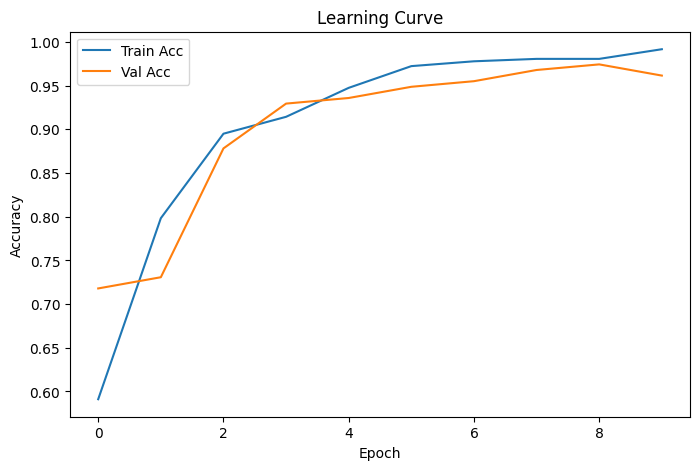

In [37]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

              precision    recall  f1-score   support

         0.0       0.93      1.00      0.96        78
         1.0       1.00      0.92      0.96        78

    accuracy                           0.96       156
   macro avg       0.96      0.96      0.96       156
weighted avg       0.96      0.96      0.96       156



2025-09-13 21:43:42.394346: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


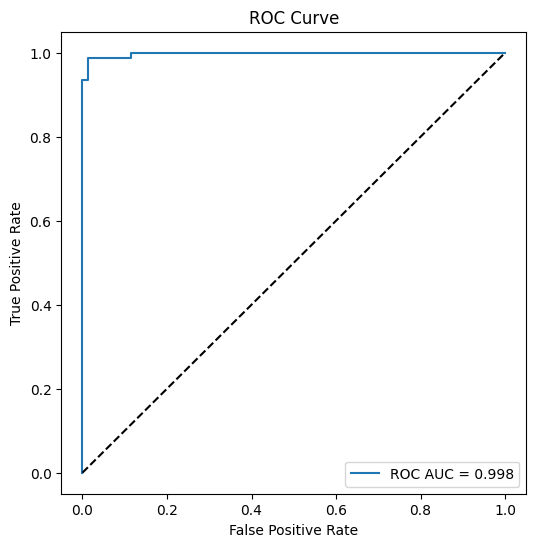

In [38]:
y_true = []
y_pred = []

for (xa, xb), y in test_ds:
    preds = model.predict([xa, xb], verbose=0)
    y_true.extend(y.numpy())
    y_pred.extend(preds.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, (y_pred>=0.5).astype(int)))

roc_auc = roc_auc_score(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_pred)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [39]:
model.save(MODEL_PATH)
print(f"✅ Model saved → {MODEL_PATH}")

✅ Model saved → siamese_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Ảnh A: images_png/phone/277646748.png
Ảnh B: images_png/phone/276281988.png
✅ Ground Truth: 1 | 🔮 Predicted: 1 (p=0.692)


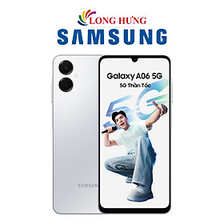

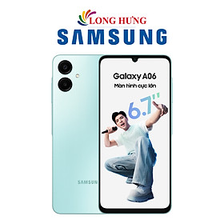

In [53]:
import random
from IPython.display import display
from PIL import Image
sample = test_df.sample(1).iloc[0]
img_a_path, img_b_path, true_label = sample["path_a"], sample["path_b"], sample["label"]

# Load & preprocess
img_a = load_and_preprocess(img_a_path)
img_b = load_and_preprocess(img_b_path)
img_a = tf.expand_dims(img_a, 0)
img_b = tf.expand_dims(img_b, 0)

# Predict
pred_prob = model.predict([img_a, img_b])[0][0]
pred_label = 1 if pred_prob >= 0.5 else 0

print(f"Ảnh A: {img_a_path}")
print(f"Ảnh B: {img_b_path}")
print(f"✅ Ground Truth: {true_label} | 🔮 Predicted: {pred_label} (p={pred_prob:.3f})")

# Hiển thị ảnh để bạn so sánh
display(Image.open(img_a_path))
display(Image.open(img_b_path))